In [1]:
# 1. Setup Environment
!pip install nvcc4jupyter xarray zarr gcsfs

In [2]:
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpp95o8vi_".


In [3]:
!pip install ninja

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.cpp_extension import load_inline
import xarray as xr
import gcsfs
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# 2. Define and Compile CUDA Kernel
cpp_source = "torch::Tensor run_weather_stencil(torch::Tensor input);"
cuda_source = '''
__global__ void weather_stencil_kernel(const float* input, float* output, int D, int H, int W) {
    int z = blockIdx.x * blockDim.x + threadIdx.x; // Depth (Levels)
    int y = blockIdx.y * blockDim.y + threadIdx.y; // Height (Lat)
    int x = blockIdx.z * blockDim.z + threadIdx.z; // Width (Lon)

    if (z > 0 && z < D - 1 && y > 0 && y < H - 1 && x > 0 && x < W - 1) {
        int idx = z * (H * W) + y * W + x;
        // 3D Laplace-style stencil
        output[idx] = 6.0f * input[idx]
                      - input[idx-1] - input[idx+1]
                      - input[idx-W] - input[idx+W]
                      - input[idx-(H*W)] - input[idx+(H*W)];
    }
}

torch::Tensor run_weather_stencil(torch::Tensor input) {
    auto output = torch::zeros_like(input);
    int D = input.size(0);
    int H = input.size(1);
    int W = input.size(2);

    // Threads arranged in 3D block
    dim3 threads(4, 8, 8);
    dim3 blocks((D + threads.x - 1) / threads.x,
                (H + threads.y - 1) / threads.y,
                (W + threads.z - 1) / threads.z);

    weather_stencil_kernel<<<blocks, threads>>>(input.data_ptr<float>(), output.data_ptr<float>(), D, H, W);
    return output;
}
'''

In [6]:
weather_cuda = load_inline(
    name='weather_cuda',
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=['run_weather_stencil'],
    with_cuda=True
)

In [7]:
# 3. Load 3D Weather Data
path = 'gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr'
fs = gcsfs.GCSFileSystem(token='anon')
ds = xr.open_zarr(gcsfs.GCSMap(path, gcs=fs), consolidated=True)

# Select 'temperature' which has (time, level, latitude, longitude)
# We take the first time step and all available levels
weather_3d = ds['temperature'].isel(time=0).values
target_3d = ds['temperature'].isel(time=1).values # Target is next time step

# Clean NaNs and move to GPU
input_tensor = torch.from_numpy(np.nan_to_num(weather_3d)).to('cuda', dtype=torch.float32)
target_tensor = torch.from_numpy(np.nan_to_num(target_3d)).to('cuda', dtype=torch.float32)

# Add this after loading target_3d
mean = input_tensor.mean()
std = input_tensor.std()

# Normalize both tensors
input_tensor = (input_tensor - mean) / std
target_tensor = (target_tensor - mean) / std

In [8]:
# 4. Run CUDA Stencil
processed_features = weather_cuda.run_weather_stencil(input_tensor)

In [9]:
# 5. 3D CNN Predictor
class WeatherPredictor3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.LeakyReLU(0.2),
            nn.Conv3d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.LeakyReLU(0.2)
        )
        # This layer maps features back to a 1-channel weather map
        self.decoder = nn.Conv3d(32, 1, kernel_size=1)

    def forward(self, x):
        identity = x # Skip connection
        out = self.encoder(x)
        out = self.decoder(out)
        return out + identity # The model now learns the "Delta" (the movement)

model = WeatherPredictor3D().cuda()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.SmoothL1Loss()

In [10]:
# 6. Training Loop
# Reshape to (Batch, Channel, Depth, Height, Width)
input_batch = processed_features[None, None, ...]
target_batch = target_tensor[None, None, ...]
scaler = torch.amp.GradScaler(device='cuda')

print("Starting Training...")
for epoch in range(1500):
    model.train()
    optimizer.zero_grad()

    # Triggering Tensor Cores via Mixed Precision
    with torch.amp.autocast(device_type='cuda'):
        prediction = model(input_batch)
        loss = criterion(prediction, target_batch)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Starting Training...
Epoch 0 | Loss: 0.439023
Epoch 50 | Loss: 0.095074
Epoch 100 | Loss: 0.066344
Epoch 150 | Loss: 0.047001
Epoch 200 | Loss: 0.035582
Epoch 250 | Loss: 0.029794
Epoch 300 | Loss: 0.026269
Epoch 350 | Loss: 0.024001
Epoch 400 | Loss: 0.020770
Epoch 450 | Loss: 0.019175
Epoch 500 | Loss: 0.018740
Epoch 550 | Loss: 0.017337
Epoch 600 | Loss: 0.016661
Epoch 650 | Loss: 0.015261
Epoch 700 | Loss: 0.025042
Epoch 750 | Loss: 0.013336
Epoch 800 | Loss: 0.013236
Epoch 850 | Loss: 0.012387
Epoch 900 | Loss: 0.011852
Epoch 950 | Loss: 0.011628
Epoch 1000 | Loss: 0.011207
Epoch 1050 | Loss: 0.011451
Epoch 1100 | Loss: 0.010351
Epoch 1150 | Loss: 0.010326
Epoch 1200 | Loss: 0.009906
Epoch 1250 | Loss: 0.010140
Epoch 1300 | Loss: 0.009546
Epoch 1350 | Loss: 0.008915
Epoch 1400 | Loss: 0.008951
Epoch 1450 | Loss: 0.009485


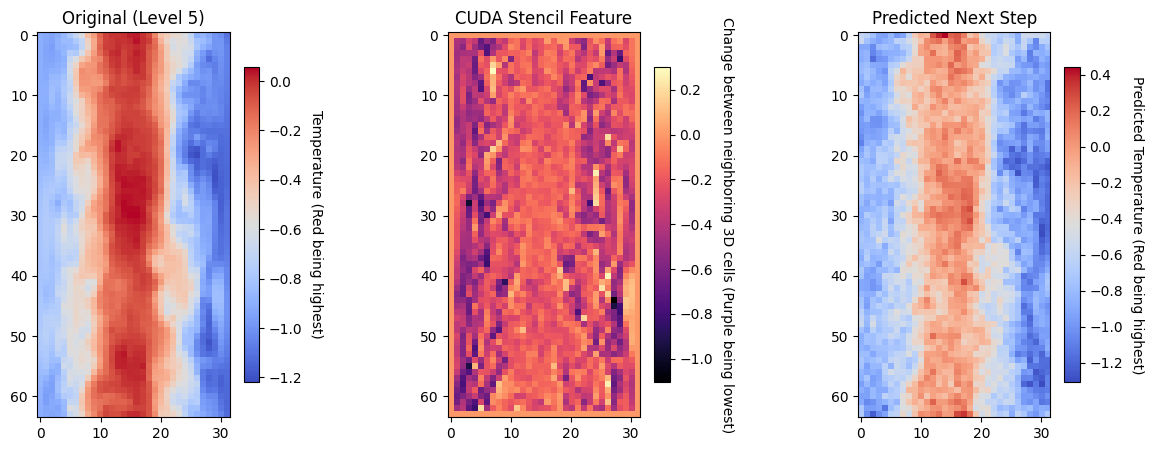

In [11]:
# 7. Visualization & Benchmark
plt.figure(figsize=(15, 5))

# Visualize a slice (Level 5) of the 3D volume
plt.subplot(1, 3, 1)
im1 = plt.imshow(input_tensor[5].cpu(), cmap='coolwarm')
plt.title("Original (Level 5)")
cbar1 = plt.colorbar(im1, fraction=0.046, pad=0.04)
cbar1.set_label('Temperature (Red being highest)', rotation=270, labelpad=15)

plt.subplot(1, 3, 2)
im2 = plt.imshow(processed_features[5].cpu(), cmap='magma')
plt.title("CUDA Stencil Feature")
cbar2 = plt.colorbar(im2, fraction=0.046, pad=0.04)
cbar2.set_label('Change between neighboring 3D cells (Purple being lowest)', rotation=270, labelpad=15)

plt.subplot(1, 3, 3)
im3 = plt.imshow(prediction[0, 0, 5].detach().cpu(), cmap='coolwarm')
plt.title("Predicted Next Step")
cbar3 = plt.colorbar(im3, fraction=0.046, pad=0.04)
cbar3.set_label('Predicted Temperature (Red being highest)', rotation=270, labelpad=15)

plt.show()

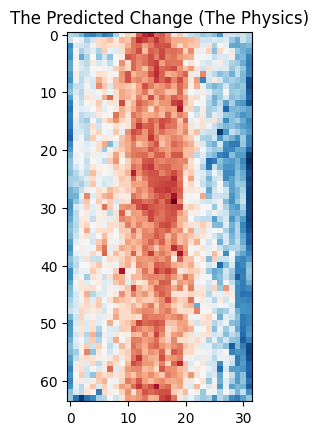

In [12]:
# To see the "Delta" or what the model actually calculated:
with torch.no_grad():
    delta = model.decoder(model.encoder(input_batch))
    plt.imshow(delta[0, 0, 5].cpu(), cmap='RdBu_r')
    plt.title("The Predicted Change (The Physics)")
    plt.show()

In [13]:
def calculate_metrics(model, input_batch, target_batch, std):
    model.eval()
    with torch.no_grad():
        prediction = model(input_batch)

        # 1. Root Mean Square Error (RMSE)
        # Most sensitive to large errors (e.g., missing a heatwave)
        mse = nn.MSELoss()(prediction, target_batch)
        rmse_norm = torch.sqrt(mse).item()
        rmse_kelvin = rmse_norm * std.item()

        # 2. Mean Absolute Error (MAE)
        # Represents the average error across the entire globe
        mae_norm = nn.L1Loss()(prediction, target_batch).item()
        mae_kelvin = mae_norm * std.item()

        # 3. Bias (Mean Error)
        # Tells you if your model is "too warm" (+) or "too cold" (-) on average
        bias_norm = torch.mean(prediction - target_batch).item()
        bias_kelvin = bias_norm * std.item()

    print("\n" + "="*30)
    print("      ACCURACY REPORT")
    print("="*30)
    print(f"RMSE: {rmse_kelvin:.4f} K")
    print(f"MAE:  {mae_kelvin:.4f} K")
    print(f"Bias: {bias_kelvin:.4f} K")
    print("="*30)

    return rmse_kelvin, mae_kelvin, bias_kelvin

# Execute the evaluation
# 'std' is the standard deviation variable you created during normalization
rmse, mae, bias = calculate_metrics(model, input_batch, target_batch, std)


      ACCURACY REPORT
RMSE: 3.7299 K
MAE:  2.7526 K
Bias: -0.7198 K


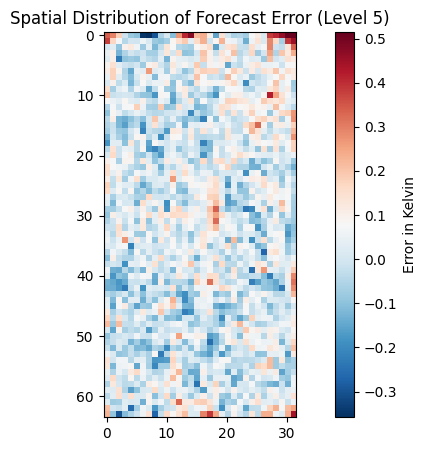

In [14]:
error_map = (prediction[0, 0, 5] - target_batch[0, 0, 5]).cpu().detach()

plt.figure(figsize=(10, 5))
plt.imshow(error_map, cmap='RdBu_r') # Red = Too hot, Blue = Too cold
plt.colorbar(label="Error in Kelvin")
plt.title("Spatial Distribution of Forecast Error (Level 5)")
plt.show()

In [15]:
# Quick Benchmark
torch.cuda.synchronize()
start = time.time()
for _ in range(100):
    _ = weather_cuda.run_weather_stencil(input_tensor)
torch.cuda.synchronize()
print(f"Avg GPU 3D Stencil Time: {(time.time() - start)/100:.6f}s")

Avg GPU 3D Stencil Time: 0.000061s


In [16]:
def benchmark_3d_stencil(input_tensor, num_iterations=100):
    # Prepare CPU data
    data_cpu = input_tensor.cpu().numpy()

    # --- 1. CPU Benchmark (Vectorized NumPy) ---
    # We use array slicing to simulate the 3D stencil without slow Python loops
    print(f"Starting CPU benchmark ({num_iterations} iterations)...")
    start_cpu = time.perf_counter()
    for _ in range(num_iterations):
        cpu_output = 6.0 * data_cpu
        # Subtract neighbors in 3D (Z, Y, X)
        cpu_output[1:-1, :, :] -= data_cpu[0:-2, :, :] # Z-1
        cpu_output[0:-2, :, :] -= data_cpu[1:-1, :, :] # Z+1
        cpu_output[:, 1:-1, :] -= data_cpu[:, 0:-2, :] # Y-1
        cpu_output[:, 0:-2, :] -= data_cpu[:, 1:-1, :] # Y+1
        cpu_output[:, :, 1:-1] -= data_cpu[:, :, 0:-2] # X-1
        cpu_output[:, :, 0:-2] -= data_cpu[:, :, 1:-1] # X+1
    end_cpu = time.perf_counter()
    t_cpu = (end_cpu - start_cpu) / num_iterations

    # --- 2. GPU Benchmark (Custom CUDA) ---
    print(f"Starting GPU benchmark ({num_iterations} iterations)...")
    # Warm-up: Vital to load kernels into GPU memory before timing
    _ = weather_cuda.run_weather_stencil(input_tensor)
    torch.cuda.synchronize()

    start_gpu = time.perf_counter()
    for _ in range(num_iterations):
        _ = weather_cuda.run_weather_stencil(input_tensor)

    # CRITICAL: Wait for GPU to finish all tasks before stopping the timer
    torch.cuda.synchronize()
    end_gpu = time.perf_counter()
    t_gpu = (end_gpu - start_gpu) / num_iterations

    # Results
    print("-" * 30)
    print(f"CPU Time (Avg): {t_cpu:.6f} seconds")
    print(f"GPU Time (Avg): {t_gpu:.6f} seconds")
    print(f"Speedup: {t_cpu/t_gpu:.2f}x")
    return t_cpu, t_gpu

# Execute
t_cpu, t_gpu = benchmark_3d_stencil(input_tensor)

Starting CPU benchmark (100 iterations)...
Starting GPU benchmark (100 iterations)...
------------------------------
CPU Time (Avg): 0.000176 seconds
GPU Time (Avg): 0.000025 seconds
Speedup: 7.16x


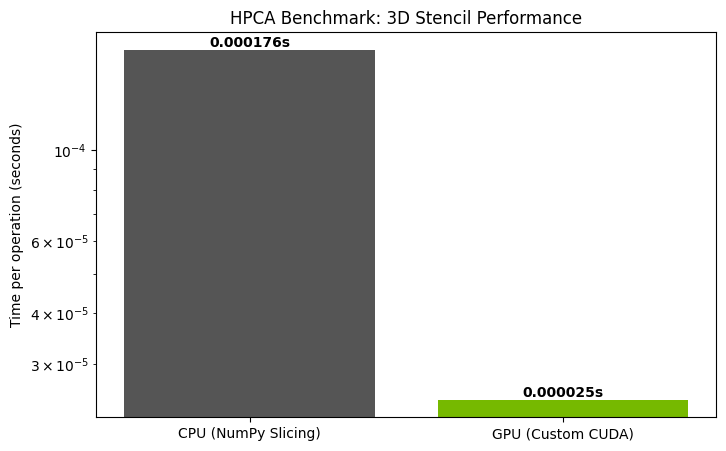

In [17]:
labels = ['CPU (NumPy Slicing)', 'GPU (Custom CUDA)']
times = [t_cpu, t_gpu]

plt.figure(figsize=(8, 5))
plt.bar(labels, times, color=['#555555', '#76b900']) # Gray and NVIDIA Green
plt.ylabel('Time per operation (seconds)')
plt.title('HPCA Benchmark: 3D Stencil Performance')
plt.yscale('log') # Log scale helps see the massive difference
for i, v in enumerate(times):
    plt.text(i, v, f"{v:.6f}s", ha='center', va='bottom', fontweight='bold')
plt.show()

In [18]:
# ============================================================
# ANIMATED WEATHER VISUALIZATION
# Add this cell AFTER your existing visualization cells.
# Requires: matplotlib, IPython (both already installed)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

# --- Pull all three volumes to CPU once ---
input_np     = input_tensor.cpu().numpy()          # t=0  (Previous)
target_np    = target_tensor.cpu().numpy()          # t=1  (Actual Next)

model.eval()
with torch.no_grad():
    pred_np  = prediction[0, 0].detach().cpu().numpy()  # t=1 (Predicted Next)

num_levels = input_np.shape[0]   # e.g. 13 pressure levels

# --- Shared colour scale (normalise across all three volumes) ---
vmin = min(input_np.min(), target_np.min(), pred_np.min())
vmax = max(input_np.max(), target_np.max(), pred_np.max())

In [19]:
# ============================================================
# ANIMATION 1 — Sweep through all pressure levels (side-by-side)
# Shows Previous | Predicted | Actual at every level
# ============================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))
fig1.patch.set_facecolor('#111111')
for ax in axes1:
    ax.set_facecolor('#111111')

titles = ["Previous (t=0)", "Predicted (t+1)", "Actual Next (t+1)"]
cmaps  = ["coolwarm", "coolwarm", "coolwarm"]

ims1   = []
for ax, title, cmap in zip(axes1, titles, cmaps):
    im = ax.imshow(np.zeros((input_np.shape[1], input_np.shape[2])),
                   cmap=cmap, vmin=vmin, vmax=vmax, animated=True)
    ax.set_title(title, color='white', fontsize=13, pad=8)
    ax.axis('off')
    cb = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Normalised Temperature', color='white', rotation=270, labelpad=15)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')
    ims1.append(im)

level_text1 = fig1.text(0.5, 0.96,
                         f"Pressure Level 0 / {num_levels-1}",
                         ha='center', va='top',
                         color='white', fontsize=14, fontweight='bold')

def update_levels(frame):
    lvl = frame % num_levels
    ims1[0].set_data(input_np[lvl])
    ims1[1].set_data(pred_np[lvl])
    ims1[2].set_data(target_np[lvl])
    level_text1.set_text(f"Pressure Level {lvl} / {num_levels-1}")
    return ims1 + [level_text1]

ani1 = animation.FuncAnimation(fig1, update_levels,
                                frames=num_levels,
                                interval=600,     # ms per frame
                                blit=True,
                                repeat=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
print("▶ Animation 1: Pressure Level Sweep")
display(HTML(ani1.to_jshtml()))
plt.close(fig1)

▶ Animation 1: Pressure Level Sweep


In [20]:
# ============================================================
# ANIMATION 2 — Difference map sweep
# Shows how much the model is wrong vs the actual change
# ============================================================
delta_actual    = target_np    - input_np          # True change
delta_predicted = pred_np      - input_np          # Model's change
error_map       = pred_np      - target_np         # Forecast error

dmax = max(np.abs(delta_actual).max(),
           np.abs(delta_predicted).max(),
           np.abs(error_map).max())

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.patch.set_facecolor('#111111')
for ax in axes2:
    ax.set_facecolor('#111111')

titles2 = ["True Δ (Actual Change)", "Predicted Δ (Model Change)", "Forecast Error"]
ims2 = []
for ax, title in zip(axes2, titles2):
    im = ax.imshow(np.zeros((input_np.shape[1], input_np.shape[2])),
                   cmap='RdBu_r', vmin=-dmax, vmax=dmax, animated=True)
    ax.set_title(title, color='white', fontsize=13, pad=8)
    ax.axis('off')
    cb = fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('ΔTemp (norm. units)', color='white', rotation=270, labelpad=15)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')
    ims2.append(im)

level_text2 = fig2.text(0.5, 0.96,
                         f"Pressure Level 0 / {num_levels-1}",
                         ha='center', va='top',
                         color='white', fontsize=14, fontweight='bold')

def update_deltas(frame):
    lvl = frame % num_levels
    ims2[0].set_data(delta_actual[lvl])
    ims2[1].set_data(delta_predicted[lvl])
    ims2[2].set_data(error_map[lvl])
    level_text2.set_text(f"Pressure Level {lvl} / {num_levels-1}")
    return ims2 + [level_text2]

ani2 = animation.FuncAnimation(fig2, update_deltas,
                                frames=num_levels,
                                interval=600,
                                blit=True,
                                repeat=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
print("▶ Animation 2: Change (Δ) and Error Maps")
display(HTML(ani2.to_jshtml()))
plt.close(fig2)

▶ Animation 2: Change (Δ) and Error Maps
